#ID-Only NCF Baseline

**Model:** Neural Collaborative Filtering (NCF) - ID embeddings only  
**Purpose:** Pure collaborative filtering baseline. No side features — only `user_id` and `book_id` embeddings.  
Establishes the performance floor that all feature-enhanced models must beat.

**Input files:** `App1_train.pkl`, `App1_val.pkl`, `App1_test.pkl`  
(produced by `12_temporal_split_ncf.ipynb`)

**Columns used:** `user_id`, `book_id`, `event_time` only.  
All other feature columns in the pkl files are ignored by this model.

**Label construction:**  
All interactions in the dataset are treated as implicit positives (label=1) — the upstream  
cleaning pipeline already removed noise (zero-rating-only users, high zero-rating users).  
Negatives are sampled at training time from the top-1000 most popular books the user has not seen.

**Evaluation:** For each test user, score all items not seen in training.  
Ground truth = the user's test interactions. Report HitRate@K, MAP@K, nDCG@K at K=10.

**Architecture source:**   
**Training loop source:**

## 0. Imports

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder

from google.colab import drive
drive.mount('/content/drive')
DATA_DIR  = '/content/drive/My Drive/BT4222Project/'

SEED = 4222
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
K = 10

print(f"Device : {DEVICE}")
print(f"K      : {K}")

Mounted at /content/drive
Device : cuda
K      : 10


## 1. Load Splits

Loads the within-user temporal splits.  
Only `user_id`, `book_id`, and `event_time` are used — all other columns ignored.

In [ ]:
train_df = pd.read_pickle(DATA_DIR + "App1_train.pkl")
val_df   = pd.read_pickle(DATA_DIR + "App1_val.pkl")
test_df  = pd.read_pickle(DATA_DIR + "App1_test.pkl")

for df in [train_df, val_df, test_df]:
    df["user_id"]    = df["user_id"].astype(str)
    df["book_id"]    = df["book_id"].astype(str)
    df["event_time"] = pd.to_datetime(df["event_time"], errors="coerce")
    df.sort_values(["user_id", "event_time"], inplace=True)
    df.reset_index(drop=True, inplace=True)

# Keep only columns needed for ID-only NCF
COLS     = ["user_id", "book_id", "event_time"]
train_df = train_df[COLS].copy()
val_df   = val_df[COLS].copy()
test_df  = test_df[COLS].copy()

print(f"Train : {len(train_df):,} rows  |  {train_df['user_id'].nunique():,} users")
print(f"Val   : {len(val_df):,} rows  |  {val_df['user_id'].nunique():,} users")
print(f"Test  : {len(test_df):,} rows  |  {test_df['user_id'].nunique():,} users")

Train : 6,017,121 rows  |  454,189 users
Val   : 1,317,799 rows  |  315,520 users
Test  : 1,435,444 rows  |  315,520 users


## 2. Label Encoding

Fit encoders on the full population across all splits so val/test IDs  
are always within the training vocabulary — following  pattern.

In [ ]:
user_enc = LabelEncoder()
item_enc = LabelEncoder()

all_users = pd.concat([train_df, val_df, test_df])["user_id"].unique()
all_items = pd.concat([train_df, val_df, test_df])["book_id"].unique()
user_enc.fit(all_users)
item_enc.fit(all_items)

num_users = len(user_enc.classes_)
num_items = len(item_enc.classes_)

# Dataset sparsity ()
N = len(pd.concat([train_df, val_df, test_df]))
sparsity = N / (num_users * num_items)
print(f"Users (U)        : {num_users:,}")
print(f"Items (I)        : {num_items:,}")
print(f"Interactions (N) : {N:,}")
print(f"Density          : {sparsity * 100:.4f}%")

def encode_df(df):
    d = df[
        df["user_id"].isin(user_enc.classes_) &
        df["book_id"].isin(item_enc.classes_)
    ].copy()
    d["user_idx"] = user_enc.transform(d["user_id"])
    d["item_idx"] = item_enc.transform(d["book_id"])
    return d

train_enc = encode_df(train_df)
val_enc   = encode_df(val_df)
test_enc  = encode_df(test_df)

print(f"\nEncoded train : {len(train_enc):,} rows")
print(f"Encoded val   : {len(val_enc):,} rows")
print(f"Encoded test  : {len(test_enc):,} rows")

Users (U)        : 454,189
Items (I)        : 123,087
Interactions (N) : 8,770,364
Density          : 0.0157%

Encoded train : 6,017,121 rows
Encoded val   : 1,317,799 rows
Encoded test  : 1,435,444 rows


## 3. Negative Sampling (Top-1000 Popular Books)

All train interactions are implicit positives (label=1).  
Negatives (label=0) are sampled from the top-1000 most interacted books  
in training that the user has not seen across any split.

**Why top-1000 only:**  
Sampling from all 116k books per user is too slow. Using popular books  
produces harder negatives - books the user could plausibly have read  
but did not — which gives a stronger training signal than random obscure books.

**1:1 positive:negative ratio** — standard CF training practice.

In [ ]:
from time import perf_counter
from tqdm.auto import tqdm

start_t = perf_counter()

# Pre-compute top-1000 most popular books by interaction count
top_1000_books = (
    train_df.groupby("book_id").size()
    .sort_values(ascending=False)
    .head(1000)
    .index.tolist()
)
print(f"Top-1000 pool size: {len(top_1000_books)}")

# Full interaction history per user across ALL splits
# (prevents sampling a book the user interacted with in val/test as a negative)
# Use encoded item indices for faster set membership checks in the main loop.
all_enc = pd.concat([train_enc[["user_id", "item_idx"]],
                     val_enc[["user_id", "item_idx"]],
                     test_enc[["user_id", "item_idx"]]], ignore_index=True)
user_full_history_idx = all_enc.groupby("user_id")["item_idx"].apply(set).to_dict()

# Build training positives
pos = train_enc[["user_idx", "item_idx"]].copy()
pos["label"] = 1

# Pre-compute maps/arrays used in the negative sampling loop
user_pos_counts = train_enc.groupby("user_id", sort=False).size()
user_to_idx = train_enc.drop_duplicates("user_id").set_index("user_id")["user_idx"].to_dict()
top_1000_idx = item_enc.transform(top_1000_books)

rng = np.random.default_rng(SEED)
neg_user_chunks, neg_item_chunks = [], []

for user_id, n_pos in tqdm(user_pos_counts.items(), total=len(user_pos_counts), desc="Negative sampling", unit="user"):
    seen_idx = user_full_history_idx.get(user_id, set())

    if seen_idx:
        # Keep only top-1000 items not seen by this user
        pool_idx = top_1000_idx[~np.isin(top_1000_idx, list(seen_idx))]
    else:
        pool_idx = top_1000_idx

    n_neg = min(int(n_pos), int(pool_idx.size))
    if n_neg == 0:
        continue

    sampled_idx = rng.choice(pool_idx, size=n_neg, replace=False)
    neg_user_chunks.append(np.full(n_neg, user_to_idx[user_id], dtype=np.int32))
    neg_item_chunks.append(sampled_idx.astype(np.int32))

if neg_user_chunks:
    neg = pd.DataFrame({
        "user_idx": np.concatenate(neg_user_chunks),
        "item_idx": np.concatenate(neg_item_chunks),
        "label": np.zeros(sum(len(x) for x in neg_user_chunks), dtype=np.int8),
    })
else:
    neg = pd.DataFrame(columns=["user_idx", "item_idx", "label"])

train_with_neg = (
    pd.concat([pos, neg], ignore_index=True)
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

print(f"Train rows (with negatives): {len(train_with_neg):,}")
print(train_with_neg["label"].value_counts())
print(f"Negative sampling time: {perf_counter() - start_t:.1f}s")

Top-1000 pool size: 1000


Negative sampling:   0%|          | 0/454189 [00:00<?, ?user/s]

Train rows (with negatives): 11,789,793
label
1    6017121
0    5772672
Name: count, dtype: int64
Negative sampling time: 56.9s


## 4. Dataset and DataLoader

In [ ]:
class GoodreadsDataset(Dataset):
    def __init__(self, df):
        self.users  = torch.tensor(df["user_idx"].values, dtype=torch.long)
        self.items  = torch.tensor(df["item_idx"].values, dtype=torch.long)
        self.labels = torch.tensor(df["label"].values,    dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.labels[idx]

# Val set: all interactions are positives for monitoring val loss
val_enc_labeled  = val_enc.copy();  val_enc_labeled["label"]  = 1
test_enc_labeled = test_enc.copy(); test_enc_labeled["label"] = 1

train_loader = DataLoader(GoodreadsDataset(train_with_neg),  batch_size=512, shuffle=True)
val_loader   = DataLoader(GoodreadsDataset(val_enc_labeled), batch_size=512, shuffle=False)
test_loader  = DataLoader(GoodreadsDataset(test_enc_labeled), batch_size=512, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")

Train batches : 23027
Val   batches : 2574
Test  batches : 2804


## 5. ID-Only NCF Model

Only `user_embedding` and `book_embedding` — no side features.

Architecture:
- User embedding (32-dim) + Book embedding (32-dim) → concat (64-dim)
- MLP: 64 → 256 → ReLU → 64 → BatchNorm → ReLU → Dropout(0.5) → 1

| Component      | Description |
|---------------|-------------|
| Input         | user_id and book_id (integer indices) only. No content or contextual features. |
| User Embedding| Learnable: 454,189 users x 32 dimensions |
| Book Embedding| Learnable: 123,087 books x 32 dimensions |
| MLP           | Linear(64->256) -> ReLU -> Linear(256->64) -> BatchNorm -> ReLU -> Dropout(0.5) -> Linear(64->1) |
| Output        | Sigmoid scalar — predicted probability of positive interaction |
| Parameters    | 18,506,113 trainable parameters |

In [ ]:
class NCFModel(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=32):
        super().__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)
        self.mlp = nn.Sequential(
            nn.Linear(2 * embedding_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1),
        )

    def forward(self, user, item):
        user_emb = self.user_embedding(user)
        item_emb = self.item_embedding(item)
        x = torch.cat([user_emb, item_emb], dim=1)
        return self.mlp(x).squeeze(1)

model = NCFModel(num_users, num_items, embedding_dim=32).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

NCFModel(
  (user_embedding): Embedding(454189, 32)
  (item_embedding): Embedding(123087, 32)
  (mlp): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=64, bias=True)
    (3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total trainable parameters: 18,506,113


## 6. Evaluation Metrics

HitRate@K, MAP@K, nDCG@K — reused from LSTM notebook.  
Scalar nDCG

In [ ]:
def hit_rate_at_k(preds, targets, k=10):
    top_k = np.argsort(-preds, axis=1)[:, :k]
    return np.mean([int(t in top) for t, top in zip(targets, top_k)])

def map_at_k(preds, targets, k=10):
    top_k = np.argsort(-preds, axis=1)[:, :k]
    ap_list = []
    for t, top in zip(targets, top_k):
        if t in top:
            rank = np.where(top == t)[0][0] + 1
            ap_list.append(1.0 / rank)
        else:
            ap_list.append(0.0)
    return np.mean(ap_list)

def ndcg_at_k_rank(preds, targets, k=10):
    top_k = np.argsort(-preds, axis=1)[:, :k]
    ndcg_list = []
    for t, top in zip(targets, top_k):
        if t in top:
            rank = np.where(top == t)[0][0] + 1
            ndcg_list.append(1.0 / np.log2(rank + 1))
        else:
            ndcg_list.append(0.0)
    return np.mean(ndcg_list)

def ndcg_at_k_scalar(relevances, k):
    """ scalar nDCG."""
    relevances = np.asarray(relevances)[:k]
    if relevances.size == 0:
        return 0.0
    dcg  = np.sum((2**relevances - 1) / np.log2(np.arange(2, relevances.size + 2)))
    idcg = np.sum((2**np.sort(relevances)[::-1] - 1) /
                  np.log2(np.arange(2, relevances.size + 2)))
    return dcg / idcg if idcg > 0 else 0.0

print("Evaluation functions ready.")

Evaluation functions ready.


## 7. Training — BCE Loss

BCE loss, Adam optimiser, early stopping, loss curve.

Epoch progress:   0%|          | 0/10 [00:00<?, ?epoch/s]

Train E01:   0%|          | 0/23027 [00:00<?, ?batch/s]

Epoch 01/10  Train Loss: 0.3917  Train Acc: 0.8241  Val Loss: 0.3872  Val Acc: 0.7845  Test Acc: 0.7975  RMSE: 0.3742  nDCG@10: 1.0000
  Saved (val loss: 0.3872)


Train E02:   0%|          | 0/23027 [00:00<?, ?batch/s]

Epoch 02/10  Train Loss: 0.3626  Train Acc: 0.8390  Val Loss: 0.3730  Val Acc: 0.7948  Test Acc: 0.8020  RMSE: 0.3629  nDCG@10: 1.0000
  Saved (val loss: 0.3730)


...

Epoch 06/10  Train Loss: 0.2816  Train Acc: 0.8774  Val Loss: 0.3713  Val Acc: 0.8240  Test Acc: 0.8167  RMSE: 0.3478  nDCG@10: 1.0000
  No improvement. Patience: 3/5


Train E07:   0%|          | 0/23027 [00:00<?, ?batch/s]

Epoch 07/10  Train Loss: 0.2710  Train Acc: 0.8825  Val Loss: 0.3732  Val Acc: 0.8227  Test Acc: 0.8144  RMSE: 0.3485  nDCG@10: 1.0000
  No improvement. Patience: 4/5


Train E08:   0%|          | 0/23027 [00:00<?, ?batch/s]

Epoch 08/10  Train Loss: 0.2619  Train Acc: 0.8868  Val Loss: 0.3798  Val Acc: 0.8249  Test Acc: 0.8153  RMSE: 0.3480  nDCG@10: 1.0000
  No improvement. Patience: 5/5

Early stopping at epoch 8.


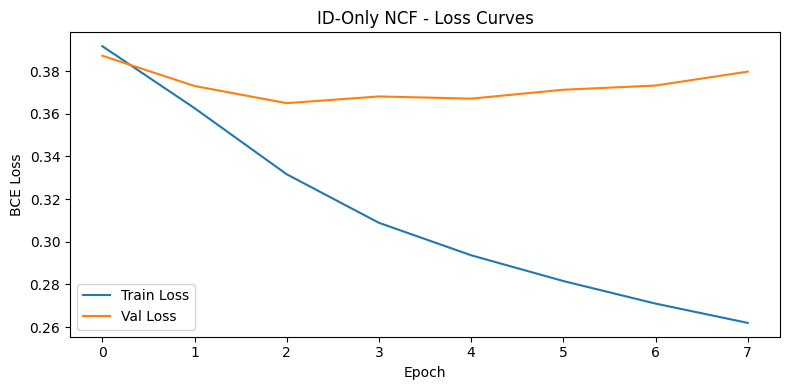

In [ ]:
from tqdm.auto import tqdm

criterion  = nn.BCELoss()
optimizer  = optim.Adam(model.parameters(), lr=0.001)

best_loss        = float("inf")
patience         = 5
patience_counter = 0
num_epochs       = 10
train_losses, val_losses = [], []

# Build test loader for per-epoch test accuracy monitoring
if "test_loader" not in globals():
    test_loader = DataLoader(GoodreadsDataset(test_enc_labeled), batch_size=512, shuffle=False)

for epoch in tqdm(range(num_epochs), desc="Epoch progress", unit="epoch"):
    # Training
    model.train()
    epoch_loss = 0.0
    train_correct = 0
    train_total = 0

    train_bar = tqdm(train_loader, desc=f"Train E{epoch+1:02d}", unit="batch", leave=False)
    for user, item, label in train_bar:
        user, item, label = user.to(DEVICE), item.to(DEVICE), label.to(DEVICE)

        optimizer.zero_grad()
        outputs = torch.sigmoid(model(user, item))
        loss = criterion(outputs, label)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        preds = (outputs >= 0.5).float()
        train_correct += (preds == label).sum().item()
        train_total += label.numel()

        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    avg_train = epoch_loss / len(train_loader)
    train_losses.append(avg_train)
    train_acc = train_correct / train_total if train_total else 0.0

    # Validation
    model.eval()
    all_probs, all_labels_v = [], []
    eval_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for user, item, label in val_loader:
            user, item, label = user.to(DEVICE), item.to(DEVICE), label.to(DEVICE)
            outputs = torch.sigmoid(model(user, item))
            eval_loss += criterion(outputs, label).item()

            preds = (outputs >= 0.5).float()
            val_correct += (preds == label).sum().item()
            val_total += label.numel()

            all_probs.extend(outputs.cpu().numpy())
            all_labels_v.extend(label.cpu().numpy())

    avg_val = eval_loss / len(val_loader)
    val_losses.append(avg_val)
    val_acc = val_correct / val_total if val_total else 0.0

    all_probs = np.array(all_probs)
    all_labels_v = np.array(all_labels_v)

    rmse = float(np.sqrt(np.mean((all_probs - all_labels_v) ** 2)))
    ndcg = float(ndcg_at_k_scalar(all_labels_v[np.argsort(all_probs)[::-1]], k=K))

    # Test accuracy (monitoring only)
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for user, item, label in test_loader:
            user, item, label = user.to(DEVICE), item.to(DEVICE), label.to(DEVICE)
            outputs = torch.sigmoid(model(user, item))
            preds = (outputs >= 0.5).float()
            test_correct += (preds == label).sum().item()
            test_total += label.numel()
    test_acc = test_correct / test_total if test_total else 0.0

    print(
        f"Epoch {epoch+1:02d}/{num_epochs}  "
        f"Train Loss: {avg_train:.4f}  Train Acc: {train_acc:.4f}  "
        f"Val Loss: {avg_val:.4f}  Val Acc: {val_acc:.4f}  "
        f"Test Acc: {test_acc:.4f}  RMSE: {rmse:.4f}  nDCG@{K}: {ndcg:.4f}"
    )

    if avg_val < best_loss:
        best_loss = avg_val
        patience_counter = 0
        torch.save(model.state_dict(), "best_ncf_idonly.pt")
        print(f"  Saved (val loss: {best_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}.")
            break

# Loss curve
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("ID-Only NCF - Loss Curves")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Ranking Evaluation — HitRate@K, MAP@K, nDCG@K

Loads best weights. For each test user, scores all items not seen in training.  
Ground truth = the user's interactions in the test split.  
Target item = first test interaction per user (next-item prediction framing).

In [ ]:
from tqdm import tqdm

model.load_state_dict(torch.load("best_ncf_idonly.pt", map_location=DEVICE))
model.eval()

user_train_seen     = train_df.groupby("user_id")["book_id"].apply(set).to_dict()
true_items_per_user = test_df.groupby("user_id")["book_id"].apply(list).to_dict()

# Pre-compute lookup dicts
item_to_idx = {item: idx for idx, item in enumerate(item_enc.classes_)}
user_to_idx = {u: idx   for idx, u   in enumerate(user_enc.classes_)}
all_book_ids = list(item_enc.classes_)

# Sample 5k test users
random.seed(SEED)
sampled_user_ids = random.sample(
    list(true_items_per_user.keys()),
    min(5000, len(true_items_per_user))
)
eval_users = [
    (uid, [b for b in true_items_per_user[uid] if b in item_to_idx])
    for uid in sampled_user_ids
    if uid in user_to_idx
]
eval_users = [(uid, books) for uid, books in eval_users if books]
print(f"Evaluating on {len(eval_users):,} sampled test users")

# Save for LSTM
pd.Series(sampled_user_ids).to_csv(DATA_DIR + "eval_sample_users.csv", index=False)

EVAL_NEG_SAMPLES = 999  # 1 positive + 999 negatives = 1000 candidates

torch.cuda.empty_cache()
import gc; gc.collect()

all_preds_rank, all_targets_rank = [], []

with torch.no_grad():
    for uid, true_books in tqdm(eval_users, desc="Evaluating Test Set"):
        uidx = user_to_idx[uid]

        target_book = true_books[0]
        target_idx  = item_to_idx[target_book]

        # Sample negatives not seen by this user
        seen     = user_train_seen.get(uid, set()) | set(true_books)
        neg_pool = [b for b in top_1000_books if b not in seen]
        negs     = random.sample(neg_pool, min(EVAL_NEG_SAMPLES, len(neg_pool)))

        # Candidate set: 1 positive + 999 negatives
        candidates    = [target_book] + negs
        candidate_idx = np.array([item_to_idx[b] for b in candidates])

        u_t = torch.tensor([uidx] * len(candidate_idx), dtype=torch.long).to(DEVICE)
        i_t = torch.tensor(candidate_idx,               dtype=torch.long).to(DEVICE)
        scores = torch.sigmoid(model(u_t, i_t)).cpu().numpy()

        # Score vector — only candidates are scored, rest stay -inf
        score_vec = np.full(num_items, -np.inf)
        for idx, score in zip(candidate_idx, scores):
            score_vec[idx] = score

        all_preds_rank.append(score_vec)
        all_targets_rank.append(target_idx)

all_preds_rank   = np.array(all_preds_rank)
all_targets_rank = np.array(all_targets_rank)

hr   = hit_rate_at_k(all_preds_rank, all_targets_rank, k=K)
mapk = map_at_k(all_preds_rank,      all_targets_rank, k=K)
ndcg = ndcg_at_k_rank(all_preds_rank, all_targets_rank, k=K)

print(f"\n  Users evaluated : {len(all_targets_rank):,}")
print(f"  HR@{K}  : {hr:.4f}")
print(f"  MAP@{K} : {mapk:.4f}")
print(f"  nDCG@{K}: {ndcg:.4f}")

Evaluating on 5,000 sampled test users


Evaluating Test Set: 100%|██████████| 5000/5000 [00:11<00:00, 444.87it/s]



  Users evaluated : 5,000
  HR@10  : 0.5312
  MAP@10 : 0.4476
  nDCG@10: 0.4670


In [ ]:
# Save sampled user IDs for use in LSTM evaluation
pd.Series(sampled_user_ids).to_csv(DATA_DIR + "eval_sample_users.csv", index=False)
print("Saved eval_sample_users.csv")

Saved eval_sample_users.csv


## 9. Performance by User Segment

Breaks down ranking metrics by dense (>= 5 training interactions) vs sparse (< 5).  
Key question: does the ID-only NCF benefit dense users more than sparse users?

In [ ]:
# Load the fixed 5k sampled user IDs
eval_sample_users_df = pd.read_csv(DATA_DIR + "eval_sample_users.csv", header=None)
eval_user_ids_fixed = eval_sample_users_df.iloc[:, -1].astype(str).tolist()

print(f"Loaded {len(eval_user_ids_fixed):,} fixed eval user IDs")
print(eval_user_ids_fixed[:5])

Loaded 5,001 fixed eval user IDs
['0', '54dd7a5fad23db1982e7ea766f5d26c1', '06026e704f0e3d084d83f389574201d1', 'd637c1fb267fd640c322a7bb02df66af', '56f8d48fda01a6ceb3a0976710d06a69']


In [ ]:
print(type(eval_users))
print(eval_users[0])

<class 'list'>
00000377eea48021d3002730d56aca9a


In [ ]:
user_train_counts = train_df.groupby("user_id").size()
dense_users  = set(user_train_counts[user_train_counts >= 5].index)
sparse_users = set(user_train_counts[user_train_counts <  5].index)

print(f"Dense  users (>= 5 train interactions): {len(dense_users):,}")
print(f"Sparse users (<  5 train interactions): {len(sparse_users):,}")

# Use the same 5k sampled eval_users from Cell 18
eval_user_ids = eval_users  # already a flat list of user IDs
results = {}

for seg_name, seg_set in [("Dense (>=5)", dense_users),
                           ("Sparse (<5)", sparse_users),
                           ("All",         set(eval_user_ids))]:
    seg_preds, seg_targets = [], []
    for i, uid in enumerate(eval_users):
      if seg_name != "All" and uid not in seg_set: continue
      if i >= len(all_preds_rank): continue
      seg_preds.append(all_preds_rank[i])
      seg_targets.append(all_targets_rank[i])

    if not seg_preds:
        print(f"\n{seg_name}: no users found")
        continue

    seg_preds   = np.array(seg_preds)
    seg_targets = np.array(seg_targets)

    hr_s   = hit_rate_at_k(seg_preds, seg_targets, k=K)
    map_s  = map_at_k(seg_preds, seg_targets, k=K)
    ndcg_s = ndcg_at_k_rank(seg_preds, seg_targets, k=K)
    results[seg_name] = {
        "n_users":      len(seg_targets),
        f"HitRate@{K}": round(hr_s, 4),
        f"MAP@{K}":     round(map_s, 4),
        f"nDCG@{K}":    round(ndcg_s, 4),
    }
    print(f"\n{seg_name} ({len(seg_targets):,} users)")
    print(f"  HitRate@{K}: {hr_s:.4f}  MAP@{K}: {map_s:.4f}  nDCG@{K}: {ndcg_s:.4f}")

seg_df = pd.DataFrame(results).T
print(f"\nSummary table:")
print(seg_df.to_string())

Dense  users (>= 5 train interactions): 184,175
Sparse users (<  5 train interactions): 270,014

Dense (>=5) (2,957 users)
  HitRate@10: 0.5326  MAP@10: 0.4507  nDCG@10: 0.4698

Sparse (<5) (2,043 users)
  HitRate@10: 0.5291  MAP@10: 0.4431  nDCG@10: 0.4630

All (5,000 users)
  HitRate@10: 0.5312  MAP@10: 0.4476  nDCG@10: 0.4670

Summary table:
             n_users  HitRate@10  MAP@10  nDCG@10
Dense (>=5)   2957.0      0.5326  0.4507   0.4698
Sparse (<5)   2043.0      0.5291  0.4431   0.4630
All           5000.0      0.5312  0.4476   0.4670


In [ ]:
user_train_counts_seg_fix = train_df.groupby("user_id").size()

def activity_bucket_3way_fix(n):
    if n <= 5:
        return "Low (1-5)"
    elif n <= 38:
        return "Medium (6-38)"
    else:
        return "High (39+)"

seg_results_3way_fix = {}

for seg_name_fix in ["Low (1-5)", "Medium (6-38)", "High (39+)", "All"]:
    seg_preds_fix, seg_targets_fix = [], []

    for idx_fix, eval_user_fix in enumerate(eval_users):
        uid_fix = eval_user_fix[0]   # extract user_id from (uid, true_books)

        n_train_fix = int(user_train_counts_seg_fix.get(uid_fix, 0))
        bucket_fix = activity_bucket_3way_fix(n_train_fix)

        if seg_name_fix != "All" and bucket_fix != seg_name_fix:
            continue
        if idx_fix >= len(all_preds_rank):
            continue

        seg_preds_fix.append(all_preds_rank[idx_fix])
        seg_targets_fix.append(all_targets_rank[idx_fix])

    if not seg_preds_fix:
        print(f"\n{seg_name_fix}: no users found")
        continue

    seg_preds_fix_arr = np.array(seg_preds_fix)
    seg_targets_fix_arr = np.array(seg_targets_fix)

    hr_fix = hit_rate_at_k(seg_preds_fix_arr, seg_targets_fix_arr, k=K)
    map_fix = map_at_k(seg_preds_fix_arr, seg_targets_fix_arr, k=K)
    ndcg_fix = ndcg_at_k_rank(seg_preds_fix_arr, seg_targets_fix_arr, k=K)

    seg_results_3way_fix[seg_name_fix] = {
        "n_users": len(seg_targets_fix_arr),
        f"HR@{K}": round(hr_fix, 4),
        f"MAP@{K}": round(map_fix, 4),
        f"nDCG@{K}": round(ndcg_fix, 4),
    }

    print(f"\n{seg_name_fix} ({len(seg_targets_fix_arr):,} users)")
    print(f"  HR@{K}: {hr_fix:.4f}  MAP@{K}: {map_fix:.4f}  nDCG@{K}: {ndcg_fix:.4f}")

seg_df_3way_fix = pd.DataFrame(seg_results_3way_fix).T
print("\nSummary table:")
print(seg_df_3way_fix.to_string())


Low (1-5) (2,337 users)
  HR@10: 0.5370  MAP@10: 0.4253  nDCG@10: 0.4514

Medium (6-38) (2,144 users)
  HR@10: 0.5065  MAP@10: 0.4394  nDCG@10: 0.4549

High (39+) (519 users)
  HR@10: 0.6069  MAP@10: 0.5816  nDCG@10: 0.5873

All (5,000 users)
  HR@10: 0.5312  MAP@10: 0.4476  nDCG@10: 0.4670

Summary table:
               n_users   HR@10  MAP@10  nDCG@10
Low (1-5)       2337.0  0.5370  0.4253   0.4514
Medium (6-38)   2144.0  0.5065  0.4394   0.4549
High (39+)       519.0  0.6069  0.5816   0.5873
All             5000.0  0.5312  0.4476   0.4670


## 10. Results Summary

Consolidated results — the baseline numbers all feature-enhanced models must beat.

In [ ]:
print("=" * 60)
print("  ID-Only NCF Baseline — Final Results Summary")
print("=" * 60)
print(f"\nRanking metrics (K={K}, full test set):")
print(f"  HitRate@{K} : {hr:.4f}")
print(f"  MAP@{K}     : {mapk:.4f}")
print(f"  nDCG@{K}    : {ndcg:.4f}")
print(f"  Users evaluated : {len(all_targets_rank):,}")
print(f"\nBy user segment:")
print(seg_df.to_string())
print(f"\nModel saved to: 13_ncf_idonly.pt")
print(f"Next: 14_NCF_Feature_Enhanced.ipynb")

  ID-Only NCF Baseline — Final Results Summary

Ranking metrics (K=10, full test set):
  HitRate@10 : 0.5312
  MAP@10     : 0.4476
  nDCG@10    : 0.4670
  Users evaluated : 5,000

By user segment:
             n_users  HitRate@10  MAP@10  nDCG@10
Dense (>=5)   2957.0      0.5326  0.4507   0.4698
Sparse (<5)   2043.0      0.5291  0.4431   0.4630
All           5000.0      0.5312  0.4476   0.4670

Model saved to: 08_ncf_idonly.pt
Next: 09_ncf_feature_enhanced.ipynb


## 11. Analysis of ID-Only NCF Baseline

The ID-only NCF baseline achieved **HitRate@10 = 0.5312**, **MAP@10 = 0.4476**, and **nDCG@10 = 0.4670** on the full test set of 5,000 users. This shows that user and item IDs alone already provide useful collaborative filtering signal, even without additional content or behavioural features.

Performance was slightly better for **dense users** than for **sparse users**, with dense users achieving marginally higher HitRate@10, MAP@10, and nDCG@10. This suggests that the model benefits from richer interaction histories, although the gap is small enough to indicate that the baseline remains reasonably stable across both user segments.

Overall, this baseline serves as a useful benchmark for later models. Any gains from the feature-enhanced NCF can therefore be interpreted as the added value of engineered features beyond the collaborative signal captured by user and item embeddings alone.